In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

# Check if we are currently inside the 'notebooks' folder
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [3]:
from src.config import SimConfig
from src.utils.data_processing import load_and_cache_entire_fleet
from src.utils.evaluation import VoyageBenchmarker

# Legacy Imports
from src.plants.fc_only_plant import FuelCellOnlyPlant
from src.solvers.sdp_baseline import BaselineSDPSolver
from src.controllers.stochastic import StochasticControl

# New Hybrid Imports
from src.plants.hybrid_plant import HybridPlant
from src.solvers.sdp_hybrid import HybridSDPSolver
from src.controllers.hybrid_controllers import (
    DiscreteTrackingControl,
    InterpolatedControl,
    LookaheadControl,
    NaiveHybridControl
)
from src.utils.plotting import plot_benchmarker_results

config = SimConfig()
fleet_data = load_and_cache_entire_fleet(config)

# Initialize benchmarker
exclude_days = [] 
benchmarker = VoyageBenchmarker(fleet_data, config, exclude_days)

Beginning memory staging of all 14 fleet files into RAM...
 -> Day 01 successfully cached in RAM.
 -> Day 02 successfully cached in RAM.
 -> Day 03 successfully cached in RAM.
 -> Day 04 successfully cached in RAM.
 -> Day 05 successfully cached in RAM.
 -> Day 06 successfully cached in RAM.
 -> Day 07 successfully cached in RAM.
 -> Day 08 successfully cached in RAM.
 -> Day 09 successfully cached in RAM.
 -> Day 10 successfully cached in RAM.
 -> Day 11 successfully cached in RAM.
 -> Day 12 successfully cached in RAM.
 -> Day 13 successfully cached in RAM.
 -> Day 14 successfully cached in RAM.

All 14 operational days securely held in RAM. Disk I/O locked.


In [9]:
# Builder wrappers for the Benchmarker cross-validation loops.
# The Benchmarker will pass the Markov Chain (mc) and Horizon dynamically.

def build_legacy_baseline(cfg, mc, horizon):
    """Legacy FC-Only operation (No battery plant)."""
    solver = BaselineSDPSolver(cfg, mc)
    policy, _ = solver.compute_solution(horizon)
    ctrl = StochasticControl(mc['levels'], cfg.n_vals, policy)
    return ctrl, FuelCellOnlyPlant(cfg)

def build_naive_hybrid(cfg, mc, horizon):
    """Battery exists in plant, but controller acts like it doesn't."""
    solver = BaselineSDPSolver(cfg, mc)
    policy, _ = solver.compute_solution(horizon)
    ctrl = NaiveHybridControl(mc['levels'], cfg.n_vals, policy)
    return ctrl, HybridPlant(cfg)

def build_discrete_tracking(cfg, mc, horizon):
    """Approach 3: Engineering Reality (Grid-locked PLC constraints)."""
    solver = HybridSDPSolver(cfg, mc)
    policy_n, policy_pbatt, _ = solver.compute_solution(horizon)
    ctrl = DiscreteTrackingControl(mc['levels'], cfg.n_vals, cfg.soc_vals, policy_n, policy_pbatt)
    return ctrl, HybridPlant(cfg)

def build_interpolated(cfg, mc, horizon):
    """Approach 2: Direct Approximation (Bilinear matrix smoothing)."""
    solver = HybridSDPSolver(cfg, mc)
    policy_n, policy_pbatt, _ = solver.compute_solution(horizon)
    ctrl = InterpolatedControl(mc['levels'], cfg.n_vals, cfg.soc_vals, policy_n, policy_pbatt)
    return ctrl, HybridPlant(cfg)

def build_lookahead(cfg, mc, horizon):
    """Approach 1: Theoretical Optimum (Online 1-step action resolution)."""
    solver = HybridSDPSolver(cfg, mc)
    _, _, V = solver.compute_solution(horizon)
    ctrl = LookaheadControl(cfg, mc['levels'], mc['P'], V)
    return ctrl, HybridPlant(cfg)

approaches = {
    "1. FC-Only Baseline": build_legacy_baseline,
    "2. Naive Hybrid (Hardware Only)": build_naive_hybrid,
    "3. Hybrid (Discrete Tracking)": build_discrete_tracking,
    "4. Hybrid (Interpolated)": build_interpolated,
    "5. Hybrid (Lookahead Optimum)": build_lookahead
}

In [13]:
print("--- APPROACH A: HAND-PICKED EVALUATION ---")
# Manually choose training block and test validation target
train_days = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
test_day = 14
df_manual = benchmarker.compare_approaches(approaches, train_days, test_day)
display(df_manual)

--- APPROACH A: HAND-PICKED EVALUATION ---


,Total Cost [€],Operating Cost [€],Switching Cost [€],Transient Cost [€],Battery Cost [€],Computation Time [s]
1. FC-Only Baseline,6509.970126,6453.720126,56.25,0.0,0.000000,0.158076
2. Naive Hybrid (Hardware Only),6474.395283,6347.437223,56.25,0.0,70.708059,0.248647
3. Hybrid (Discrete Tracking),6176.851795,6033.505683,56.25,0.0,87.096112,0.655595
4. Hybrid (Interpolated),6160.639332,6022.695557,56.25,0.0,81.693775,0.628789
5. Hybrid (Lookahead Optimum),6045.574642,5952.720896,0.00,0.0,92.853746,0.650548



--- APPROACH B: LEAVE-ONE-OUT (Discrete Tracking vs Baseline) ---


,Total Cost [€],Operating Cost [€],Switching Cost [€],Transient Cost [€],Battery Cost [€],Computation Time [s]
Day 1,2395.903354,2339.653354,56.25,0.0,0.0,0.155463
Day 2,2320.641499,2264.391499,56.25,0.0,0.0,0.165516
Day 3,7552.170682,7495.920682,56.25,0.0,0.0,0.158104
Day 4,8577.905125,8521.655125,56.25,0.0,0.0,0.161538
Day 5,6547.270194,6491.020194,56.25,0.0,0.0,0.156538
Day 6,6735.501000,6679.251000,56.25,0.0,0.0,0.150793
Day 7,6874.922406,6818.672406,56.25,0.0,0.0,0.155963
Day 8,6733.091683,6676.841683,56.25,0.0,0.0,0.157387
Day 9,7963.844510,7907.594510,56.25,0.0,0.0,0.160073
Day 10,7401.472439,7345.222439,56.25,0.0,0.0,0.154847


,Total Cost [€],Operating Cost [€],Switching Cost [€],Transient Cost [€],Battery Cost [€],Computation Time [s]
Day 1,2428.162677,2345.101209,56.25,0.0,26.811468,0.673082
Day 2,2364.952415,2281.612175,56.25,0.0,27.090240,0.668147
Day 3,7155.748674,7061.631367,56.25,0.0,37.867307,0.644116
Day 4,8220.604860,8068.763391,56.25,0.0,95.591469,0.649460
Day 5,6441.145041,6329.846021,56.25,0.0,55.049020,0.675554
Day 6,6500.425890,6369.688613,56.25,0.0,74.487277,0.645753
Day 7,6556.679481,6408.506241,56.25,0.0,91.923240,0.652538
Day 8,6519.709758,6385.664264,56.25,0.0,77.795494,0.671150
Day 9,7636.033159,7494.877882,56.25,0.0,84.905277,0.644985
Day 10,7098.858236,6970.853669,56.25,0.0,71.754566,0.759382


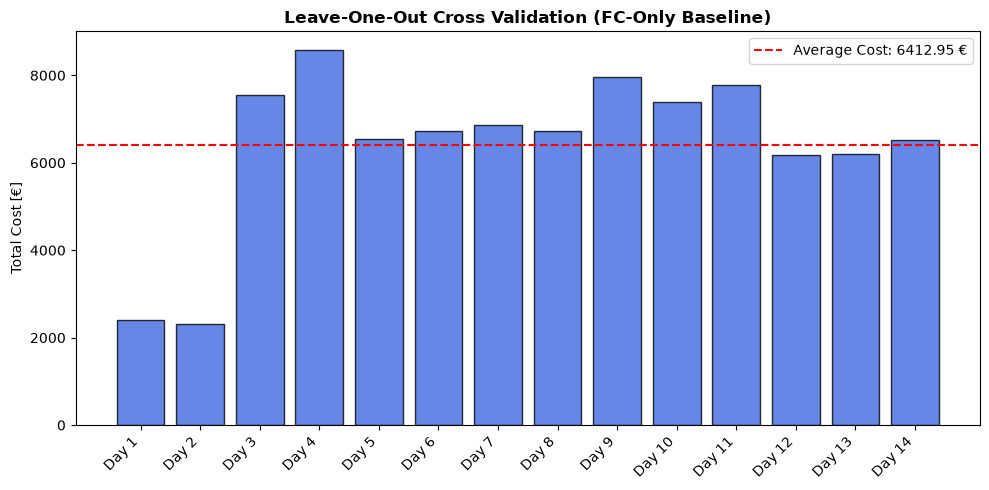

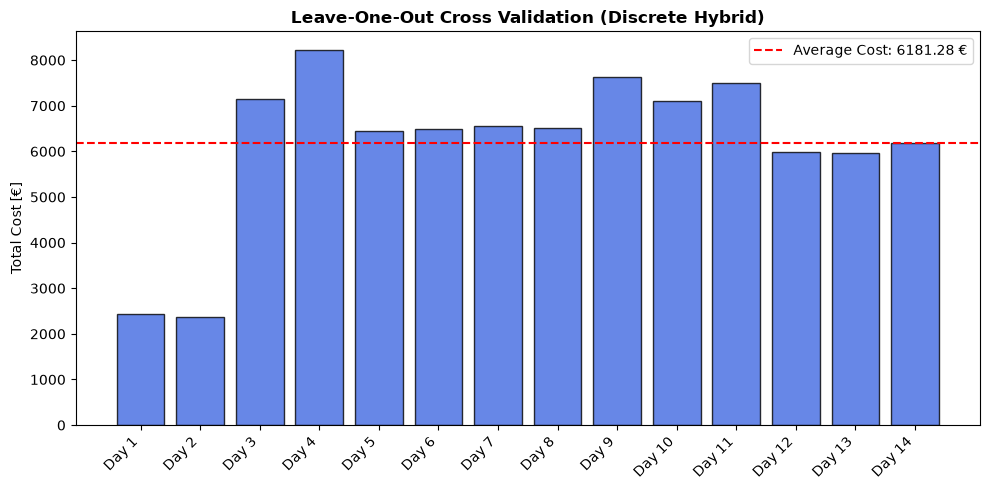

In [11]:
print("\n--- APPROACH B: LEAVE-ONE-OUT (Discrete Tracking vs Baseline) ---")

# Note: Running LOO on all 5 approaches might take a couple of minutes due to 4D solves.
# Let's compare the main engineering deployable hybrid against the legacy baseline.

df_loo_legacy = benchmarker.run_leave_one_out(approaches["1. FC-Only Baseline"])
display(df_loo_legacy)

df_loo_hybrid = benchmarker.run_leave_one_out(approaches["3. Hybrid (Discrete Tracking)"])
display(df_loo_hybrid)

# Visualize the day-to-day volatility
plot_benchmarker_results(df_loo_legacy, title="Leave-One-Out Cross Validation (FC-Only Baseline)", plot_type='bar')
plot_benchmarker_results(df_loo_hybrid, title="Leave-One-Out Cross Validation (Discrete Hybrid)", plot_type='bar')


--- APPROACH C: FORWARD CHAINING (Learning Curve) ---


,Total Cost [€],Operating Cost [€],Switching Cost [€],Transient Cost [€],Battery Cost [€],Computation Time [s]
Train 1-1 -> Test 2,2181.807128,2164.614178,0.000000,0.0,17.192950,0.876095
Train 1-2 -> Test 3,18726.818715,17806.415323,900.000000,0.0,20.403392,0.932222
Train 1-3 -> Test 4,8597.409173,8408.567053,112.500000,0.0,76.342120,0.714298
Train 1-4 -> Test 5,6353.869399,6297.450436,0.000000,0.0,56.418963,0.741227
Train 1-5 -> Test 6,6367.138474,6290.556031,0.000000,0.0,76.582444,0.682830
Train 1-6 -> Test 7,6459.646030,6372.708671,0.000000,0.0,86.937359,0.726333
Train 1-7 -> Test 8,6409.100976,6328.722829,0.000000,0.0,80.378148,0.938383
Train 1-8 -> Test 9,7517.610338,7432.284528,0.000000,0.0,85.325810,0.808901
Train 1-9 -> Test 10,6938.230285,6862.884514,0.000000,0.0,75.345771,0.716685
Train 1-10 -> Test 11,7365.001689,7266.176512,0.000000,0.0,98.825177,0.727890


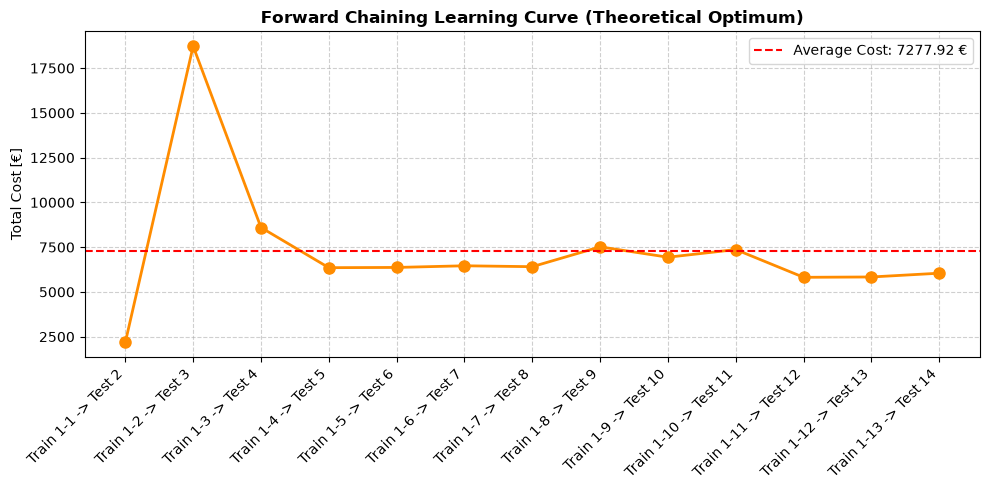

In [12]:
print("\n--- APPROACH C: FORWARD CHAINING (Learning Curve) ---")
# Evaluate how the policy improves as the agent gathers chronological data
# Using the Lookahead Optimum to see the absolute theoretical ceiling of the ship's capabilities

df_for_opt = benchmarker.run_forward_chaining(approaches["5. Hybrid (Lookahead Optimum)"])
display(df_for_opt)

plot_benchmarker_results(df_for_opt, title="Forward Chaining Learning Curve (Theoretical Optimum)", plot_type='line')